# BSD35k DEFT mild-loss v4 score generation

목적:
- BSD10k 전체 데이터로 mild weighted loss 5-class / binary confidence MLP를 최종 재학습한다.
- BSD35k-CS에 BSD10k와 동일한 입력 feature를 만든다.
- 최종 5-class / binary 모델을 BSD35k-CS에 적용해서 v4-style score를 생성한다.
- `deft_loss_v4.ipynb`에서 만든 OOF logistic/ridge stacker와 목적별 threshold 파일이 있으면 BSD35k-CS에도 같이 적용한다.

입력 구조는 04 실험과 동일하게 `audio embedding + text embedding + class one-hot + similarity/margin scalar feature`이며, 모델 구조도 `Linear(input, 32) -> ReLU -> Dropout(0.2) -> Linear`이다.

In [1]:
from pathlib import Path
import json
import math
import pickle
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
ROOT = Path.cwd()
if ROOT.name == 'deft논문기반_실험':
    ROOT = ROOT.parent

EXP_DIR = ROOT / 'deft논문기반_실험'
OUT_DIR = EXP_DIR / 'bsd35k_deft_loss_v4_outputs'
PRED_DIR = OUT_DIR / 'predictions'
MODEL_DIR = OUT_DIR / 'models'
REPORT_DIR = OUT_DIR / 'reports'
PLOT_DIR = OUT_DIR / 'plots'
for d in [PRED_DIR, MODEL_DIR, REPORT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BSD10K_META = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'
BSD35K_META = ROOT / 'data' / 'metadata' / 'BSD35k-CS_metadata.csv'

BSD10K_AUDIO_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
BSD10K_TEXT_DIR = ROOT / 'data' / 'features' / 'clap_text_embeddings'
BSD35K_AUDIO_DIR = ROOT / 'data' / 'features' / 'BSD35k_clap_audio_embeddings'
BSD35K_TEXT_DIR = ROOT / 'data' / 'features' / 'BSD35k-CS_clap_text_embeddings'

PREV_V4_DIR = EXP_DIR / 'deft_loss_v4_outputs'
PREV_STACKER_PATH = PREV_V4_DIR / 'models' / 'final_oof_stackers.pkl'
PREV_BEST_THRESHOLD_PATH = PREV_V4_DIR / 'reports' / 'deft_loss_v4_best_by_objective.csv'
PREV_FOLD_SUMMARY_PATH = PREV_V4_DIR / 'reports' / 'base_oof_fold_summary.csv'

LOSS_WEIGHTS = {1: 5.0, 2: 1.5, 3: 1.0, 4: 1.0, 5: 1.0}
DROPOUT = 0.2
HIDDEN_DIM = 32
BATCH_SIZE = 256
PRED_BATCH_SIZE = 2048
DEFAULT_FINAL_EPOCHS = 40

print('ROOT:', ROOT)
print('OUT_DIR:', OUT_DIR)
print('device:', device)
print('LOSS_WEIGHTS:', LOSS_WEIGHTS)

ROOT: c:\Users\solok\Desktop\Dcase baseline
OUT_DIR: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\bsd35k_deft_loss_v4_outputs
device: cuda
LOSS_WEIGHTS: {1: 5.0, 2: 1.5, 3: 1.0, 4: 1.0, 5: 1.0}


## 1. 동일 feature 생성 함수

여기서는 BSD10k text embedding으로 class prototype을 만들고, BSD10k와 BSD35k 모두에 동일한 방식으로 scalar feature를 계산한다.

Scalar feature:
- `audio_text_sim`: audio embedding과 text embedding cosine similarity
- `audio_class_sim`: audio embedding과 해당 class prototype similarity
- `audio_assigned_label_margin`: 해당 class similarity - 다른 class 중 최고 similarity
- `text_assigned_label_margin`: text embedding 기준 동일 margin

In [3]:
SCALAR_FEATURE_NAMES = [
    'audio_text_sim',
    'audio_class_sim',
    'audio_assigned_label_margin',
    'text_assigned_label_margin',
]

def path_map(folder: Path):
    if not folder.exists():
        raise FileNotFoundError(f'Missing folder: {folder}')
    return {p.stem: p for p in folder.glob('*.npy')}

def load_vector(path: Path) -> np.ndarray:
    arr = np.load(path)
    return arr.reshape(-1).astype(np.float32)

def normalize_rows(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + eps)

def aligned_metadata(meta_path: Path, audio_dir: Path, text_dir: Path, require_confidence: bool):
    meta = pd.read_csv(meta_path)
    audio_paths = path_map(audio_dir)
    text_paths = path_map(text_dir)
    rows = []
    missing_audio = 0
    missing_text = 0
    for _, row in meta.iterrows():
        sid = str(int(row['sound_id'])) if pd.notna(row['sound_id']) else str(row['sound_id'])
        has_audio = sid in audio_paths
        has_text = sid in text_paths
        if not has_audio:
            missing_audio += 1
        if not has_text:
            missing_text += 1
        if not (has_audio and has_text):
            continue
        if require_confidence and pd.isna(row.get('confidence', np.nan)):
            continue
        out = row.to_dict()
        out['_sound_id_str'] = sid
        out['_audio_path'] = audio_paths[sid]
        out['_text_path'] = text_paths[sid]
        rows.append(out)
    df = pd.DataFrame(rows).reset_index(drop=True)
    return df, {'raw_rows': len(meta), 'usable_rows': len(df), 'missing_audio': missing_audio, 'missing_text': missing_text}

def load_embedding_matrices(df: pd.DataFrame):
    audio = np.stack([load_vector(Path(p)) for p in df['_audio_path']], axis=0)
    text = np.stack([load_vector(Path(p)) for p in df['_text_path']], axis=0)
    return audio.astype(np.float32), text.astype(np.float32)

def build_class_prototypes(df10: pd.DataFrame, text10: np.ndarray, class_categories):
    text_norm = normalize_rows(text10)
    prototypes = []
    for cls in class_categories:
        idx = (df10['class'].astype(str).to_numpy() == cls)
        if not idx.any():
            raise ValueError(f'No BSD10k rows for class: {cls}')
        prototypes.append(text_norm[idx].mean(axis=0))
    return normalize_rows(np.stack(prototypes, axis=0).astype(np.float32))

def build_feature_matrix(df: pd.DataFrame, audio: np.ndarray, text: np.ndarray, class_categories, class_prototypes):
    class_to_idx = {cls: i for i, cls in enumerate(class_categories)}
    n = len(df)
    class_ids = np.array([class_to_idx.get(str(c), -1) for c in df['class']], dtype=np.int64)
    class_onehot = np.zeros((n, len(class_categories)), dtype=np.float32)
    known = class_ids >= 0
    class_onehot[np.where(known)[0], class_ids[known]] = 1.0

    audio_norm = normalize_rows(audio)
    text_norm = normalize_rows(text)
    audio_text_sim = np.sum(audio_norm * text_norm, axis=1)

    audio_class_all = audio_norm @ class_prototypes.T
    text_class_all = text_norm @ class_prototypes.T

    audio_class_sim = np.zeros(n, dtype=np.float32)
    audio_margin = np.zeros(n, dtype=np.float32)
    text_margin = np.zeros(n, dtype=np.float32)
    for i in range(n):
        cls_idx = class_ids[i]
        if cls_idx < 0:
            continue
        audio_scores = audio_class_all[i]
        text_scores = text_class_all[i]
        other_mask = np.ones(len(class_categories), dtype=bool)
        other_mask[cls_idx] = False
        audio_class_sim[i] = audio_scores[cls_idx]
        audio_margin[i] = audio_scores[cls_idx] - audio_scores[other_mask].max()
        text_margin[i] = text_scores[cls_idx] - text_scores[other_mask].max()

    scalar_features = np.column_stack([
        audio_text_sim,
        audio_class_sim,
        audio_margin,
        text_margin,
    ]).astype(np.float32)

    x_full = np.concatenate([audio, text, class_onehot, scalar_features], axis=1).astype(np.float32)
    feature_info = {
        'audio_dim': int(audio.shape[1]),
        'text_dim': int(text.shape[1]),
        'class_onehot_dim': int(class_onehot.shape[1]),
        'scalar_dim': int(scalar_features.shape[1]),
        'input_dim': int(x_full.shape[1]),
        'unknown_class_rows': int((~known).sum()),
    }
    scalar_df = pd.DataFrame(scalar_features, columns=SCALAR_FEATURE_NAMES)
    return x_full, class_onehot, scalar_df, feature_info

In [4]:
bsd10_df, bsd10_align = aligned_metadata(BSD10K_META, BSD10K_AUDIO_DIR, BSD10K_TEXT_DIR, require_confidence=True)
bsd35_df, bsd35_align = aligned_metadata(BSD35K_META, BSD35K_AUDIO_DIR, BSD35K_TEXT_DIR, require_confidence=False)

audio10, text10 = load_embedding_matrices(bsd10_df)
audio35, text35 = load_embedding_matrices(bsd35_df)

class_categories = sorted(bsd10_df['class'].astype(str).unique().tolist())
class_prototypes = build_class_prototypes(bsd10_df, text10, class_categories)

X10, class_oh10, scalar10, info10 = build_feature_matrix(bsd10_df, audio10, text10, class_categories, class_prototypes)
X35, class_oh35, scalar35, info35 = build_feature_matrix(bsd35_df, audio35, text35, class_categories, class_prototypes)

y5 = bsd10_df['confidence'].astype(int).to_numpy() - 1
yb = (bsd10_df['confidence'].astype(int).to_numpy() >= 4).astype(int)
sample_weight = np.asarray([LOSS_WEIGHTS[int(c)] for c in bsd10_df['confidence'].astype(int)], dtype=np.float32)

print('BSD10k align:', bsd10_align)
print('BSD35k align:', bsd35_align)
print('BSD10k feature:', info10)
print('BSD35k feature:', info35)
print('class count:', len(class_categories))
print('X10:', X10.shape, 'X35:', X35.shape)

BSD10k align: {'raw_rows': 10956, 'usable_rows': 10956, 'missing_audio': 0, 'missing_text': 0}
BSD35k align: {'raw_rows': 33829, 'usable_rows': 33829, 'missing_audio': 0, 'missing_text': 0}
BSD10k feature: {'audio_dim': 512, 'text_dim': 512, 'class_onehot_dim': 23, 'scalar_dim': 4, 'input_dim': 1051, 'unknown_class_rows': 0}
BSD35k feature: {'audio_dim': 512, 'text_dim': 512, 'class_onehot_dim': 23, 'scalar_dim': 4, 'input_dim': 1051, 'unknown_class_rows': 2365}
class count: 23
X10: (10956, 1051) X35: (33829, 1051)


## 2. BSD10k 전체 final model 학습

`deft_loss_v4_outputs/reports/base_oof_fold_summary.csv`가 있으면 OOF에서 관측된 best epoch의 중앙값을 final epoch로 사용한다. 없으면 `DEFAULT_FINAL_EPOCHS=40`으로 학습한다.

In [5]:
class ConfidenceMLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_dim: int = 32, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

def final_epochs_from_oof(default_epochs: int = DEFAULT_FINAL_EPOCHS):
    if not PREV_FOLD_SUMMARY_PATH.exists():
        return default_epochs, default_epochs, 'fallback_default'
    fold_df = pd.read_csv(PREV_FOLD_SUMMARY_PATH)
    if not {'5class_best_epoch', 'binary_best_epoch'}.issubset(fold_df.columns):
        return default_epochs, default_epochs, 'fallback_missing_columns'
    e5 = max(5, int(round(float(fold_df['5class_best_epoch'].median()))))
    eb = max(5, int(round(float(fold_df['binary_best_epoch'].median()))))
    return e5, eb, 'median_oof_best_epoch'

FINAL_EPOCHS_5CLASS, FINAL_EPOCHS_BINARY, EPOCH_SOURCE = final_epochs_from_oof()
print('FINAL_EPOCHS_5CLASS:', FINAL_EPOCHS_5CLASS)
print('FINAL_EPOCHS_BINARY:', FINAL_EPOCHS_BINARY)
print('EPOCH_SOURCE:', EPOCH_SOURCE)

FINAL_EPOCHS_5CLASS: 5
FINAL_EPOCHS_BINARY: 5
EPOCH_SOURCE: median_oof_best_epoch


In [6]:
def train_final_model(x: np.ndarray, y: np.ndarray, weights: np.ndarray, output_dim: int, epochs: int, tag: str):
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x).astype(np.float32)

    ds = TensorDataset(
        torch.from_numpy(x_scaled),
        torch.from_numpy(y.astype(np.int64)),
        torch.from_numpy(weights.astype(np.float32)),
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

    model = ConfidenceMLP(x.shape[1], output_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_n = 0
        for xb, yb_, wb in loader:
            xb = xb.to(device)
            yb_ = yb_.to(device)
            wb = wb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss_per = F.cross_entropy(logits, yb_, reduction='none')
            loss = (loss_per * wb).mean()
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().cpu()) * len(xb)
            total_n += len(xb)
        row = {'epoch': epoch, 'train_loss': total_loss / max(total_n, 1)}
        history.append(row)
        if epoch == 1 or epoch == epochs or epoch % 10 == 0:
            print(f'[{tag}] epoch {epoch:03d}/{epochs:03d} loss={row["train_loss"]:.5f}')
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(REPORT_DIR / f'{tag}_final_train_history.csv', index=False, encoding='utf-8-sig')
    return model, scaler, hist_df

model_5class, scaler_5class, hist5 = train_final_model(X10, y5, sample_weight, output_dim=5, epochs=FINAL_EPOCHS_5CLASS, tag='5class')
model_binary, scaler_binary, histb = train_final_model(X10, yb, sample_weight, output_dim=2, epochs=FINAL_EPOCHS_BINARY, tag='binary_123_45')

[5class] epoch 001/005 loss=1.32099
[5class] epoch 005/005 loss=1.03689
[binary_123_45] epoch 001/005 loss=0.64896
[binary_123_45] epoch 005/005 loss=0.54805


In [7]:
feature_description = {
    'input': 'audio embedding + text embedding + BSD10k class one-hot + four similarity/margin scalar features',
    'scalar_features': SCALAR_FEATURE_NAMES,
    'class_categories': class_categories,
    'bsd10k_feature_info': info10,
    'bsd35k_feature_info': info35,
}
model_description = {
    'architecture': 'Linear(input, 32) -> ReLU -> Dropout(0.2) -> Linear(output)',
    'loss_weights': LOSS_WEIGHTS,
    'final_epochs_5class': FINAL_EPOCHS_5CLASS,
    'final_epochs_binary': FINAL_EPOCHS_BINARY,
    'epoch_source': EPOCH_SOURCE,
}

torch.save({
    'model_state_dict': model_5class.state_dict(),
    'feature_description': feature_description,
    'model_description': model_description,
}, MODEL_DIR / 'bsd10k_final_mild_loss_5class_mlp.pt')
torch.save({
    'model_state_dict': model_binary.state_dict(),
    'feature_description': feature_description,
    'model_description': model_description,
}, MODEL_DIR / 'bsd10k_final_mild_loss_binary_123_45_mlp.pt')
with open(MODEL_DIR / 'bsd10k_final_scalers.pkl', 'wb') as f:
    pickle.dump({'5class': scaler_5class, 'binary': scaler_binary}, f)
(REPORT_DIR / 'class_mapping.json').write_text(json.dumps({'class_categories': class_categories}, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved final models/scalers')

saved final models/scalers


## 3. BSD35k score 생성

In [8]:
@torch.no_grad()
def predict_proba(model: nn.Module, scaler: StandardScaler, x: np.ndarray, batch_size: int = PRED_BATCH_SIZE):
    model.eval()
    x_scaled = scaler.transform(x).astype(np.float32)
    probs = []
    for start in range(0, len(x_scaled), batch_size):
        xb = torch.from_numpy(x_scaled[start:start + batch_size]).to(device)
        p = torch.softmax(model(xb), dim=1).detach().cpu().numpy()
        probs.append(p)
    return np.vstack(probs)

def normalized_entropy(prob: np.ndarray):
    prob = np.clip(prob, 1e-8, 1.0)
    return -np.sum(prob * np.log(prob), axis=1) / math.log(prob.shape[1])

def build_score_frame(df: pd.DataFrame, prob5: np.ndarray, probb: np.ndarray, scalar_df: pd.DataFrame):
    keep_cols = [c for c in ['sound_id', 'class', 'class_idx', 'class_top', 'uploader', 'license', 'title', 'tags', 'description'] if c in df.columns]
    out = df[keep_cols].copy()
    for i in range(5):
        out[f'prob_confidence_{i + 1}'] = prob5[:, i]
    out['pred_confidence'] = prob5.argmax(axis=1) + 1
    out['binary_mild_prob123'] = probb[:, 0]
    out['binary_mild_prob45'] = probb[:, 1]
    out['binary_pred_45_at_0p5'] = (out['binary_mild_prob45'] >= 0.5).astype(int)

    conf_values = np.arange(1, 6, dtype=np.float32)
    out['fiveclass_expected_score'] = prob5 @ conf_values
    out['fiveclass_expected_score_01'] = (out['fiveclass_expected_score'] - 1.0) / 4.0
    out['fiveclass_p45'] = prob5[:, 3] + prob5[:, 4]
    out['fiveclass_margin_p45_minus_p3'] = out['fiveclass_p45'] - prob5[:, 2]
    out['fiveclass_entropy'] = normalized_entropy(prob5)
    out['binary_entropy'] = normalized_entropy(probb)

    rank_binary = pd.Series(out['binary_mild_prob45']).rank(pct=True).to_numpy()
    rank_expected = pd.Series(out['fiveclass_expected_score_01']).rank(pct=True).to_numpy()
    out['rank_avg_binary_expected_p45'] = (rank_binary + rank_expected) / 2.0

    for col in SCALAR_FEATURE_NAMES:
        out[col] = scalar_df[col].to_numpy()
    return out

prob5_35 = predict_proba(model_5class, scaler_5class, X35)
probb_35 = predict_proba(model_binary, scaler_binary, X35)
score35 = build_score_frame(bsd35_df, prob5_35, probb_35, scalar35)
score35.head()

,sound_id,class,class_idx,class_top,uploader,license,title,tags,description,prob_confidence_1,...,fiveclass_expected_score_01,fiveclass_p45,fiveclass_margin_p45_minus_p3,fiveclass_entropy,binary_entropy,rank_avg_binary_expected_p45,audio_text_sim,audio_class_sim,audio_assigned_label_margin,text_assigned_label_margin
0,796088,fx-h,404,fx,randbsoundbites,http://creativecommons.org/publicdomain/zero/1.0/,Finger Snap,"Click,Fingers,Snap",A sound effect of a single finger snap. Could ...,0.002628,...,0.648298,0.613127,0.247491,0.485464,0.923231,0.504804,0.658293,-0.000982,-0.207630,-0.254016
1,796133,fx-n,406,fx,haydonsound,https://creativecommons.org/licenses/by/4.0/,"Birdsong,Wind Noise and Footsteps","birdsong,nature,wildlife",Recorded in mono with an SE7,0.017919,...,0.594500,0.462204,-0.003852,0.603620,0.968470,0.605782,0.255341,0.122687,-0.386708,-0.328755
2,796149,ss-n,501,ss,klankbeeld,https://creativecommons.org/licenses/by/4.0/,chats in national park Loonse en Drunense Duin...,"ambient,autumn,background-sound,calm,chat,day-...",Distend conversation in the heath landscape on...,0.032768,...,0.614919,0.569080,0.223261,0.620366,0.990556,0.513435,0.482886,0.280114,-0.031635,0.136875
3,796181,ss-n,501,ss,klankbeeld,https://creativecommons.org/licenses/by/4.0/,park ambiance Loonse en Drunense Duinen 0912 A...,"ambience,ambient,atmospheric,birds,birdsong,ca...","Spring morning in Dutch park. <a href=""https...",0.020490,...,0.655965,0.678217,0.428845,0.615669,0.820447,0.850188,0.367875,0.374315,0.060434,0.247522
4,796221,is-e,205,is,daaverali,https://creativecommons.org/licenses/by/4.0/,Sample ST-58:rsstring,"Amiga,Lead,rsstring,Sample,Saw,Sawtooth,ST","<a href=""https://modsamplemaster.thegang.nu/sa...",0.025064,...,0.488326,0.292304,-0.048671,0.822496,0.796554,0.118079,0.217067,0.138111,-0.101339,-0.164212


## 4. v4 stacker와 threshold 적용

`deft_loss_v4.ipynb`를 끝까지 실행해서 `final_oof_stackers.pkl`과 `deft_loss_v4_best_by_objective.csv`가 있으면 자동으로 적용한다. 아직 없으면 base score만 저장한다.

In [9]:
def slugify(text):
    text = str(text).lower()
    text = re.sub(r'[^0-9a-zA-Z가-힣]+', '_', text).strip('_')
    return text[:80] if text else 'value'

stacker_applied = False
if PREV_STACKER_PATH.exists():
    with open(PREV_STACKER_PATH, 'rb') as f:
        stacker_obj = pickle.load(f)
    stack_features = stacker_obj['stack_features']
    missing = [c for c in stack_features if c not in score35.columns]
    if missing:
        warnings.warn(f'Stacker feature missing, skip stacker: {missing}')
    else:
        X_stack35 = score35[stack_features].to_numpy(dtype=np.float32)
        score35['logistic_stacker_prob45'] = stacker_obj['logistic'].predict_proba(X_stack35)[:, 1]
        score35['ridge_stacker_score45'] = np.clip(stacker_obj['ridge'].predict(X_stack35), 0.0, 1.0)
        stacker_applied = True
        print('applied stackers:', stack_features)
else:
    print('stacker file not found, base scores only:', PREV_STACKER_PATH)

threshold_applied_rows = []
if PREV_BEST_THRESHOLD_PATH.exists():
    best_df = pd.read_csv(PREV_BEST_THRESHOLD_PATH)
    required = {'method', 'objective', 'score_column', 'threshold'}
    if required.issubset(best_df.columns):
        for _, row in best_df.iterrows():
            score_col = row['score_column']
            if score_col not in score35.columns:
                continue
            threshold = float(row['threshold'])
            sel_col = 'select_' + slugify(row['method']) + '_' + slugify(row['objective'])
            score35[sel_col] = (score35[score_col] >= threshold).astype(int)
            threshold_applied_rows.append({
                'method': row['method'],
                'objective': row['objective'],
                'score_column': score_col,
                'threshold': threshold,
                'selection_column': sel_col,
                'selected_rows': int(score35[sel_col].sum()),
                'selected_ratio': float(score35[sel_col].mean()),
            })
    else:
        warnings.warn(f'best threshold file has unexpected columns: {best_df.columns.tolist()}')
else:
    print('best threshold file not found, threshold columns skipped:', PREV_BEST_THRESHOLD_PATH)

threshold_apply_df = pd.DataFrame(threshold_applied_rows)
if len(threshold_apply_df):
    display(threshold_apply_df)
else:
    print('no threshold columns applied')

applied stackers: ['binary_mild_prob45', 'fiveclass_expected_score_01', 'fiveclass_p45', 'fiveclass_margin_p45_minus_p3', 'prob_confidence_1', 'prob_confidence_2', 'prob_confidence_3', 'prob_confidence_4', 'prob_confidence_5', 'fiveclass_entropy', 'binary_entropy']


,method,objective,score_column,threshold,selection_column,selected_rows,selected_ratio
0,OOF ridge stacker,F1-optimal,ridge_stacker_score45,0.386,select_oof_ridge_stacker_f1_optimal,25541,0.755003
1,OOF ridge stacker,macro-F1-optimal,ridge_stacker_score45,0.569,select_oof_ridge_stacker_macro_f1_optimal,10612,0.313695
2,rank average: binary + expected + P45,balanced recall 123/45,rank_avg_binary_expected_p45,0.454,select_rank_average_binary_expected_p45_balanc...,18470,0.545981
3,rank average: binary + expected + P45,precision-optimal @ recall>=0.70,rank_avg_binary_expected_p45,0.436,select_rank_average_binary_expected_p45_precis...,19147,0.565994
4,rank average: binary + expected + P45,recall-optimal @ precision>=0.70,rank_avg_binary_expected_p45,0.225,select_rank_average_binary_expected_p45_recall...,27162,0.802921


In [10]:
base_path = PRED_DIR / 'BSD35k-CS_deft_loss_v4_base_scores.csv'
full_path = PRED_DIR / 'BSD35k-CS_deft_loss_v4_scores.csv'

base_cols = [
    'sound_id', 'class', 'class_idx', 'class_top',
    'prob_confidence_1', 'prob_confidence_2', 'prob_confidence_3', 'prob_confidence_4', 'prob_confidence_5',
    'pred_confidence', 'binary_mild_prob45', 'fiveclass_expected_score', 'fiveclass_expected_score_01',
    'fiveclass_p45', 'fiveclass_margin_p45_minus_p3', 'fiveclass_entropy', 'binary_entropy',
    'rank_avg_binary_expected_p45',
]
base_cols = [c for c in base_cols if c in score35.columns]
score35[base_cols].to_csv(base_path, index=False, encoding='utf-8-sig')
score35.to_csv(full_path, index=False, encoding='utf-8-sig')

if len(threshold_apply_df):
    threshold_apply_df.to_csv(REPORT_DIR / 'BSD35k-CS_deft_loss_v4_threshold_application_summary.csv', index=False, encoding='utf-8-sig')

summary = {
    'bsd10k_alignment': bsd10_align,
    'bsd35k_alignment': bsd35_align,
    'bsd10k_feature_info': info10,
    'bsd35k_feature_info': info35,
    'loss_weights': LOSS_WEIGHTS,
    'model_description': model_description,
    'stacker_applied': bool(stacker_applied),
    'threshold_rows_applied': int(len(threshold_apply_df)),
    'base_score_file': str(base_path),
    'full_score_file': str(full_path),
}
(REPORT_DIR / 'bsd35k_deft_loss_v4_score_generation_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=float), encoding='utf-8')

print('saved base:', base_path)
print('saved full:', full_path)
print('rows:', len(score35))

saved base: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\bsd35k_deft_loss_v4_outputs\predictions\BSD35k-CS_deft_loss_v4_base_scores.csv
saved full: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\bsd35k_deft_loss_v4_outputs\predictions\BSD35k-CS_deft_loss_v4_scores.csv
rows: 33829


## 5. Score 분포 확인

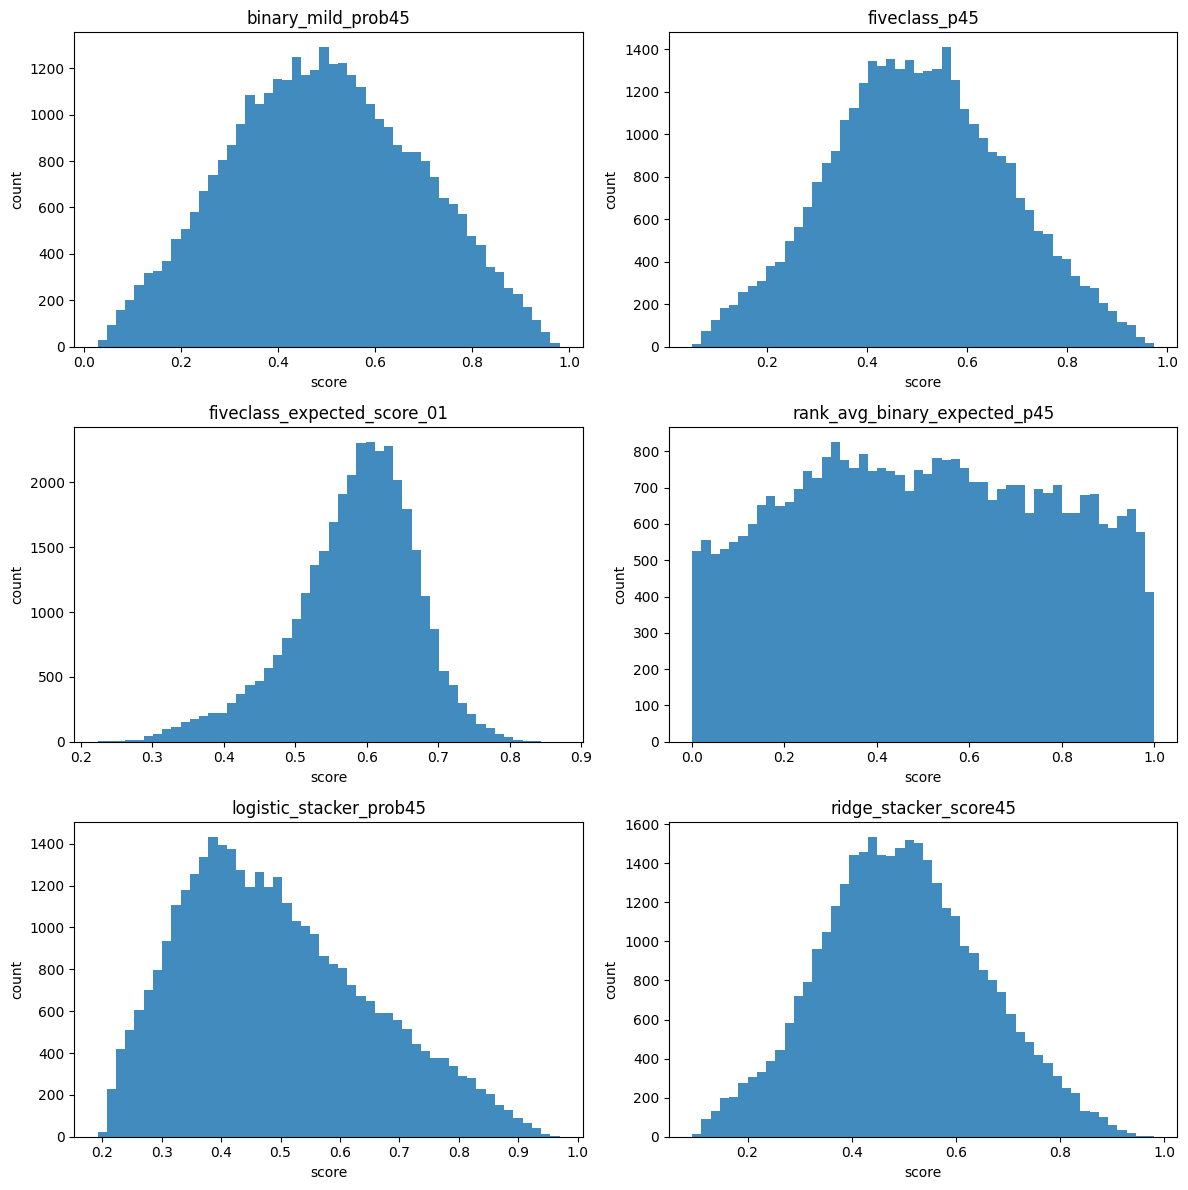

In [11]:
plot_cols = [
    'binary_mild_prob45',
    'fiveclass_p45',
    'fiveclass_expected_score_01',
    'rank_avg_binary_expected_p45',
    'logistic_stacker_prob45',
    'ridge_stacker_score45',
]
plot_cols = [c for c in plot_cols if c in score35.columns]

ncols = 2
nrows = math.ceil(len(plot_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = np.asarray(axes).reshape(-1)
for ax, col in zip(axes, plot_cols):
    ax.hist(score35[col].to_numpy(dtype=float), bins=50, alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('score')
    ax.set_ylabel('count')
for ax in axes[len(plot_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'BSD35k-CS_deft_loss_v4_score_distributions.png', dpi=180)
plt.show()

In [12]:
score_preview_cols = [
    'sound_id', 'class', 'pred_confidence', 'binary_mild_prob45', 'fiveclass_p45',
    'fiveclass_expected_score', 'rank_avg_binary_expected_p45',
    'logistic_stacker_prob45', 'ridge_stacker_score45',
]
score_preview_cols = [c for c in score_preview_cols if c in score35.columns]
display(score35[score_preview_cols].sort_values(score_preview_cols[-1], ascending=False).head(20))
display(score35[score_preview_cols].describe(include='all'))

,sound_id,class,pred_confidence,binary_mild_prob45,fiveclass_p45,fiveclass_expected_score,rank_avg_binary_expected_p45,logistic_stacker_prob45,ridge_stacker_score45
14609,816709,sp-s,5,0.933749,0.968564,4.478407,0.998300,0.969576,0.980849
20004,825374,is-p,4,0.964478,0.941559,4.362525,0.999793,0.964889,0.977740
26268,833436,sp-s,4,0.945210,0.961791,4.408564,0.999098,0.964980,0.976024
10379,811112,m-sp,4,0.967043,0.970571,4.223624,0.999527,0.945293,0.960506
5841,805666,is-p,4,0.923902,0.944652,4.362912,0.997251,0.956927,0.952528
10169,810858,is-p,4,0.953471,0.936833,4.238685,0.999246,0.950388,0.951869
21086,826768,is-p,4,0.934801,0.954329,4.305199,0.998359,0.950757,0.951535
25362,832367,m-sp,4,0.969692,0.973315,4.141497,0.998566,0.932419,0.948157
8380,808722,is-p,4,0.929852,0.932905,4.301414,0.997783,0.950536,0.943980
20819,826401,sp-s,4,0.935714,0.967763,4.215416,0.998079,0.936024,0.939320


,sound_id,class,pred_confidence,binary_mild_prob45,fiveclass_p45,fiveclass_expected_score,rank_avg_binary_expected_p45,logistic_stacker_prob45,ridge_stacker_score45
count,33829.000000,33829,33829.000000,33829.000000,33829.000000,33829.000000,33829.000000,33829.000000,33829.000000
unique,NaN,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,ss-n,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,820514.269148,NaN,3.604718,0.493676,0.501401,3.330419,0.500015,0.492664,0.496615
std,13327.263547,NaN,0.606425,0.193689,0.175453,0.344366,0.273688,0.157719,0.155558
min,796088.000000,NaN,1.000000,0.026881,0.050097,1.893205,0.000384,0.192051,0.093729
25%,808834.000000,NaN,3.000000,0.351171,0.378464,3.136079,0.274971,0.371487,0.388693
50%,819704.000000,NaN,4.000000,0.490724,0.497674,3.372949,0.497753,0.470671,0.491610
75%,832376.000000,NaN,4.000000,0.634087,0.623177,3.564799,0.730704,0.598445,0.601236
